In [ ]:
# 1. Save your Kaggle API token
!mkdir -p ~/.kaggle && echo KGAT_af2d818147604db4ba56c49f427fc52d > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

# 2. Download and unzip EuroSAT
!kaggle datasets download -d apollo2506/eurosat-dataset
!unzip -q eurosat-dataset.zip -d /content/EuroSAT_RGB

Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
100% 2.04G/2.04G [02:17<00:00, 16.0MB/s]



In [ ]:
!pip install fastai

In [ ]:
import torch
import torchvision.models as models
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 1. Define Image Transforms (Matching your guide)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Point directly to the extracted RGB dataset folder
dataset_path = '/content/EuroSAT_RGB/EuroSAT'
full_dataset = datasets.ImageFolder(root=dataset_path, transform=train_transform)

# 3. Split: 80% Train, 10% Validation, 10% Test
train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_set, val_set, test_set = random_split(full_dataset, [train_size, val_size, test_size])

# Apply test_transform to validation and test splits
val_set.dataset.transform = test_transform
test_set.dataset.transform = test_transform

# 4. Create DataLoaders with batch size 32
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

print(f"Data ready! Total: {len(full_dataset)} | Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

Data ready! Total: 27000 | Train: 21600 | Val: 2700 | Test: 2700


In [ ]:
# Load pretrained ResNet50
model = models.resnet50(pretrained=True)

# Freeze all layers except the final one
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully-connected layer to output 10 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

# Move model to GPU (cuda)
model = model.to('cuda')

print("ResNet50 built and moved to GPU!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 207MB/s]


ResNet50 built and moved to GPU!


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to('cuda')
        labels = labels.to('cuda')

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation step
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to('cuda')
            labels = labels.to('cuda')
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = correct / total
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}, Val Accuracy: {val_accuracy:.4f}')

Epoch 1/10, Loss: 0.4755, Val Accuracy: 0.9256
Epoch 2/10, Loss: 0.2815, Val Accuracy: 0.9193
Epoch 3/10, Loss: 0.2530, Val Accuracy: 0.9311
Epoch 4/10, Loss: 0.2364, Val Accuracy: 0.9456
Epoch 5/10, Loss: 0.2212, Val Accuracy: 0.9396
Epoch 6/10, Loss: 0.2219, Val Accuracy: 0.9493
Epoch 7/10, Loss: 0.2074, Val Accuracy: 0.9430
Epoch 8/10, Loss: 0.1965, Val Accuracy: 0.9363
Epoch 9/10, Loss: 0.2015, Val Accuracy: 0.9370
Epoch 10/10, Loss: 0.1906, Val Accuracy: 0.9470


In [ ]:
# Unfreeze all model layers
for param in model.parameters():
    param.requires_grad = True

# Optimizer at 10x lower learning rate
optimizer = optim.Adam(model.parameters(), lr=0.0001)
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to('cuda')
        labels = labels.to('cuda')

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to('cuda')
            labels = labels.to('cuda')
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = correct / total
    print(f'Fine-Tune Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}, Val Accuracy: {val_accuracy:.4f}')

Fine-Tune Epoch 1/5, Loss: 0.2014, Val Accuracy: 0.9741
Fine-Tune Epoch 2/5, Loss: 0.0666, Val Accuracy: 0.9815
Fine-Tune Epoch 3/5, Loss: 0.0513, Val Accuracy: 0.9793
Fine-Tune Epoch 4/5, Loss: 0.0485, Val Accuracy: 0.9778
Fine-Tune Epoch 5/5, Loss: 0.0402, Val Accuracy: 0.9819


              precision    recall  f1-score   support

  AnnualCrop       0.98      0.95      0.97       309
      Forest       0.99      0.98      0.98       313
     HerbVeg       0.97      0.97      0.97       266
     Highway       0.95      1.00      0.97       255
  Industrial       0.99      0.98      0.99       243
     Pasture       0.97      0.95      0.96       227
    PermCrop       0.94      0.97      0.95       247
 Residential       0.99      1.00      0.99       285
       River       0.98      0.98      0.98       255
     SeaLake       0.99      0.99      0.99       300

    accuracy                           0.98      2700
   macro avg       0.98      0.98      0.98      2700
weighted avg       0.98      0.98      0.98      2700



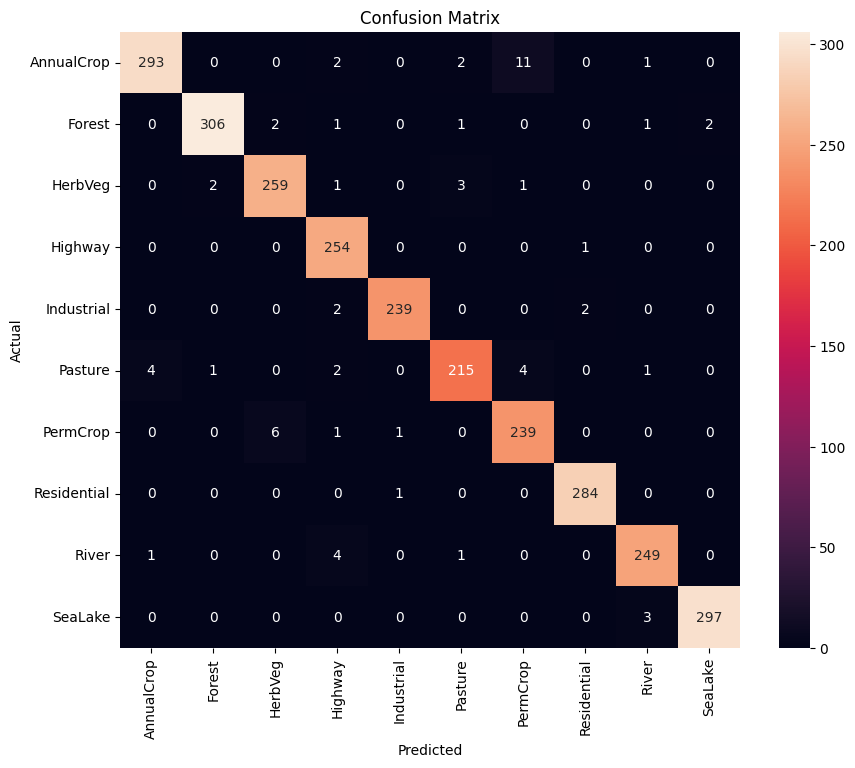

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to('cuda')
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

class_names = ['AnnualCrop', 'Forest', 'HerbVeg', 'Highway', 'Industrial', 'Pasture', 'PermCrop', 'Residential', 'River', 'SeaLake']

# Print classification report
print(classification_report(all_labels, all_preds, target_names=class_names))

# Generate and save confusion matrix plot
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

In [ ]:
# Save model weights locally in Colab
import torch
torch.save(model.state_dict(), 'eurosat_resnet50.pth')

In [1]:
from PIL import Image
img = Image.open('satellite_2018.tif')
width, height = img.size
patches_2018 = []
for i in range(0, width - 64, 64):
    for j in range(0, height - 64, 64):
        patch = img.crop((i, j, i + 64, j + 64))
        patches_2018.append((patch, i, j))

In [3]:
from PIL import Image
img = Image.open('satellite_2024.tif')
width, height = img.size
patches_2024 = []
for i in range(0, width - 64, 64):
    for j in range(0, height - 64, 64):
        patch = img.crop((i, j, i + 64, j + 64))
        patches_2024.append((patch, i, j))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Classifying 2018 patches...
Classifying 2026 patches...
2018 patches: 2704 | 2026 patches: 2704 | Overlapping coords: 2704
Detected 22 deforestation events.
Saved to /content/deforestation_map.png


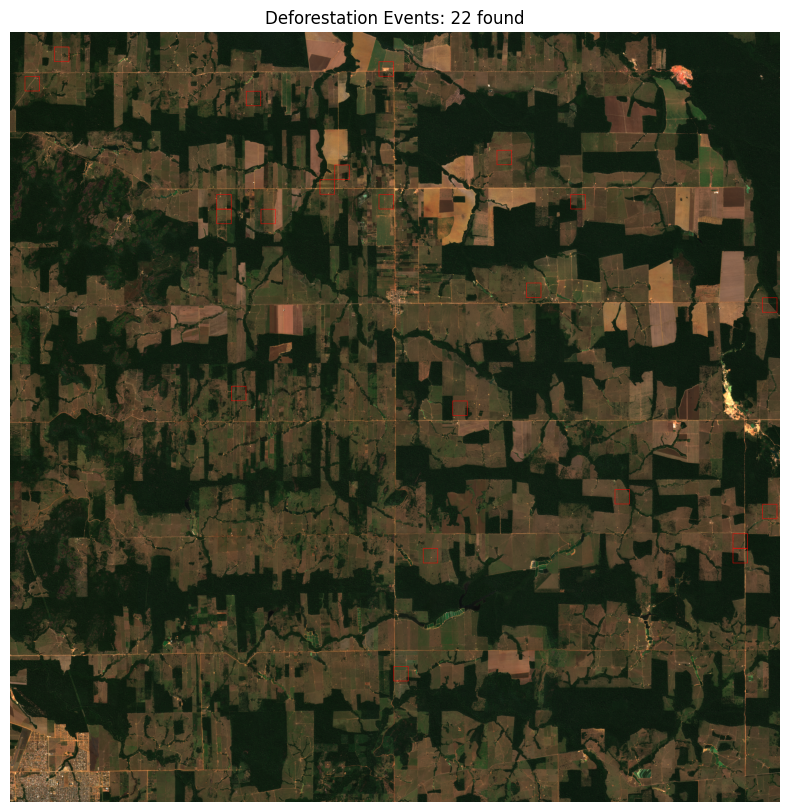

In [4]:
import torch
import torchvision.models as models
import torch.nn as nn
from torchvision import transforms
from PIL import ImageDraw
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load your trained model
model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 10)
model.load_state_dict(torch.load('eurosat_resnet50.pth', map_location=device))
model = model.to(device).eval()

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class_names = ['AnnualCrop', 'Forest', 'HerbVeg', 'Highway', 'Industrial',
               'Pasture', 'PermCrop', 'Residential', 'River', 'SeaLake']
def_targets = ['AnnualCrop', 'Pasture', 'Industrial', 'Residential']

def classify_patches(patch_list):
    cover_map = {}
    with torch.no_grad():
        for patch, x, y in patch_list:
            img_tensor = test_transform(patch).unsqueeze(0).to(device)
            outputs = model(img_tensor)
            _, predicted = torch.max(outputs, 1)
            cover_map[(x, y)] = class_names[predicted.item()]
    return cover_map

# Classify both years
print("Classifying 2018 patches...")
map_2018 = classify_patches(patches_2018)
print("Classifying 2026 patches...")
map_2024 = classify_patches(patches_2024)

# Diagnostics — this tells you exactly where it's breaking if nothing shows up
overlap = set(map_2018) & set(map_2024)
print(f"2018 patches: {len(map_2018)} | 2026 patches: {len(map_2024)} | Overlapping coords: {len(overlap)}")

# Find deforestation events
deforestation_events = []
for (x, y) in overlap:
    class_2018 = map_2018[(x, y)]
    class_2024 = map_2024[(x, y)]
    if class_2018 == 'Forest' and class_2024 in def_targets:
        deforestation_events.append(((x, y), class_2018, class_2024))

print(f"Detected {len(deforestation_events)} deforestation events.")

# Draw and save
original_img = Image.open('satellite_2018.tif').convert("RGB")
draw = ImageDraw.Draw(original_img)
patch_size = 64

for (x, y), _, _ in deforestation_events:
    draw.rectangle([x, y, x + patch_size, y + patch_size], outline=(255, 0, 0), width=2)

output_path = '/content/deforestation_map.png'
original_img.save(output_path)
print(f"Saved to {output_path}")

plt.figure(figsize=(10, 10))
plt.imshow(original_img)
plt.title(f'Deforestation Events: {len(deforestation_events)} found')
plt.axis('off')
plt.show()
